# Bayesian Inference in ML

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply basic Bayesian inference
- Update priors with likelihood; interpret posteriors
- Connect Bayesian ideas to ML (e.g. uncertainty)

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 04 "Probabilistic Reasoning: Bayes' Theorem" — prior, likelihood and posterior for single events; here the same rule updates whole distributions.

**Used later in:** Course 04 (AIAT 114) — Unit 3, lesson 05 "Random Forest and Naive Bayes Classifiers" — a classifier built entirely out of this rule.

---


# Bayesian Inference in ML

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 2: Statistical Inference** - Understand hypothesis testing
- ✅ **Basic understanding**: What is Bayesian inference?

**If you haven't completed these**, you might struggle with:
- Understanding Bayesian vs frequentist
- Understanding prior and posterior
- Applying Bayesian methods

---

## 🔗 Where This Notebook Fits

**This is the THIRD example of Module 05** - advanced inference!

**Why this example THIRD?**
- **Before** you can understand Bayesian methods, you need frequentist methods (Example 2)
- **Before** you can use Bayesian ML, you need Bayesian inference

**Builds on**: Example 2 (statistical inference)

**Leads to**: Advanced ML topics

---

## The Story: Understanding Before Using

Imagine updating your beliefs as you learn. **Before** you have prior beliefs. **After** seeing data, you update to posterior beliefs. This is Bayesian inference!

Same with machine learning: **Before** training, we have prior beliefs about parameters. **After** seeing data, we update to posterior beliefs using Bayesian inference!

---

## Why This Concept Matters

### Why Bayesian Inference Matters

**WHY** is Bayesian inference important?

1. **Prior Knowledge**:
   - **WHY**: Can incorporate prior knowledge
   - **HOW**: Use prior distributions
   - **AFTER**: Better use of information

2. **Uncertainty Quantification**:
   - **WHY**: Provides full uncertainty distribution
   - **HOW**: Compute posterior distribution
   - **AFTER**: Better uncertainty estimates

3. **Regularization**:
   - **WHY**: Priors act as regularization
   - **HOW**: Prior constrains parameters
   - **AFTER**: Better generalization

## Learning Objectives
1. Understand Bayesian inference
2. Understand prior and posterior
3. Apply to ML scenarios

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this works in ML!

---

## 🌉 Bridge: The Ingredients — Bernoulli/Binomial, Likelihood, and Beta

The example below uses three terms this unit has not formally introduced yet. Working definitions (the binomial reappears in notebook 06, where **likelihood** gets its full treatment):

1. **Bernoulli / binomial model.** A Bernoulli trial is a single yes/no outcome with success probability p (one free throw, one click). Repeat n independent trials and count the successes k: that count follows the **binomial distribution**.
2. **Likelihood.** For observed data "k successes in n trials", the probability of that data for a candidate p is P(data | p) = C(n,k) · pᵏ(1−p)ⁿ⁻ᵏ. Read as a function of p, this is the **likelihood**: it scores how well each candidate p explains the data.
3. **Beta distribution.** A distribution over p itself (values in [0, 1]) with shape parameters α and β — think "α−1 successes and β−1 failures already believed in". It is the natural **prior** for a probability.

**Why Beta + binomial pair so well (conjugacy):** multiply a Beta(α, β) prior by a binomial likelihood with k successes in n trials, and the posterior is again a Beta — **Beta(α + k, β + n − k)**. Updating beliefs becomes simple addition. The next cell shows the ingredients separately before we combine them.

Data: 8 successes in 10 trials
Likelihood peaks at p ≈ 0.80 (= k/n = 0.80)


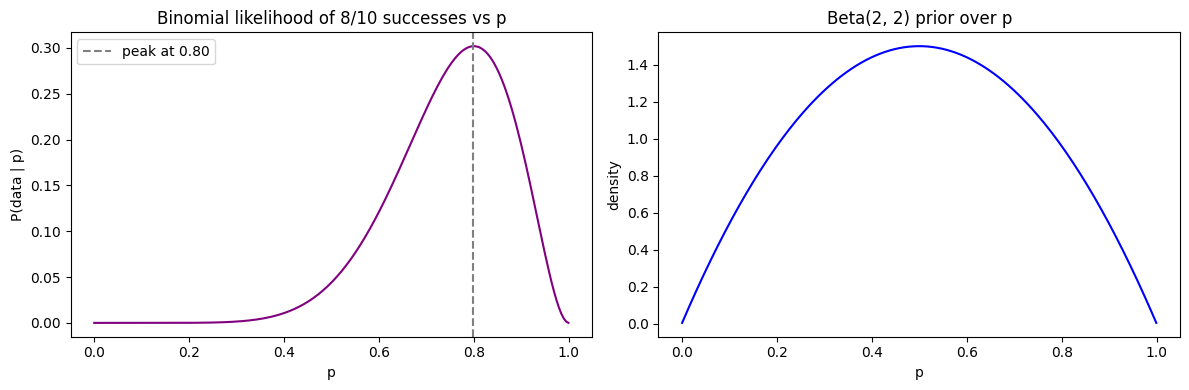


Next: combine this prior with this likelihood → a Beta posterior (conjugate update)


In [2]:
# Bridge demo: the binomial likelihood and the Beta prior, shown separately
from scipy import stats

n_trials, k_successes = 10, 8
p_grid = np.linspace(0.001, 0.999, 200)

# Likelihood of "8 successes in 10 trials" as a function of p
likelihood = stats.binom.pmf(k_successes, n_trials, p_grid)
p_best = p_grid[np.argmax(likelihood)]
print(f"Data: {k_successes} successes in {n_trials} trials")
print(f"Likelihood peaks at p ≈ {p_best:.2f} (= k/n = {k_successes / n_trials:.2f})")

# Beta(2, 2): a mild prior centered at 0.5
prior_pdf = stats.beta.pdf(p_grid, 2, 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(p_grid, likelihood, color='purple')
axes[0].axvline(p_best, color='gray', linestyle='--', label=f'peak at {p_best:.2f}')
axes[0].set_title(f'Binomial likelihood of {k_successes}/{n_trials} successes vs p')
axes[0].set_xlabel('p')
axes[0].set_ylabel('P(data | p)')
axes[0].legend()
axes[1].plot(p_grid, prior_pdf, color='blue')
axes[1].set_title('Beta(2, 2) prior over p')
axes[1].set_xlabel('p')
axes[1].set_ylabel('density')
plt.tight_layout()
plt.show()

print("\nNext: combine this prior with this likelihood → a Beta posterior (conjugate update)")

## Step 2: Implementation

**BEFORE**: We understand the concept.

**AFTER**: We'll see HOW it's implemented!

In [3]:
# Example 1: Bayesian Inference
# WHY: Incorporate prior knowledge and quantify uncertainty
# HOW: Update prior beliefs with data to get posterior

# Simple example: Estimating a probability
# Prior: Beta distribution (conjugate prior for binomial)
alpha_prior = 2  # Prior belief
beta_prior = 2

# Data: 8 successes out of 10 trials
successes = 8
trials = 10

# Posterior: Beta(alpha_prior + successes, beta_prior + failures)
alpha_posterior = alpha_prior + successes
beta_posterior = beta_prior + (trials - successes)

# Compute posterior mean
posterior_mean = alpha_posterior / (alpha_posterior + beta_posterior)

print("Example 1: Bayesian Inference")
print("=" * 60)
print(f"Prior: Beta({alpha_prior}, {beta_prior})")
print(f"Data: {successes} successes out of {trials} trials")
print(f"Posterior: Beta({alpha_posterior}, {beta_posterior})")
print(f"Posterior mean (probability): {posterior_mean:.4f}")
print(f"\n💡 WHY: Incorporates prior knowledge")
print(f"💡 HOW: Update prior with data → posterior")
print(f"💡 AFTER: Better estimates with uncertainty!")

Example 1: Bayesian Inference
Prior: Beta(2, 2)
Data: 8 successes out of 10 trials
Posterior: Beta(10, 4)
Posterior mean (probability): 0.7143

💡 WHY: Incorporates prior knowledge
💡 HOW: Update prior with data → posterior
💡 AFTER: Better estimates with uncertainty!


---

## 📊 Visualization

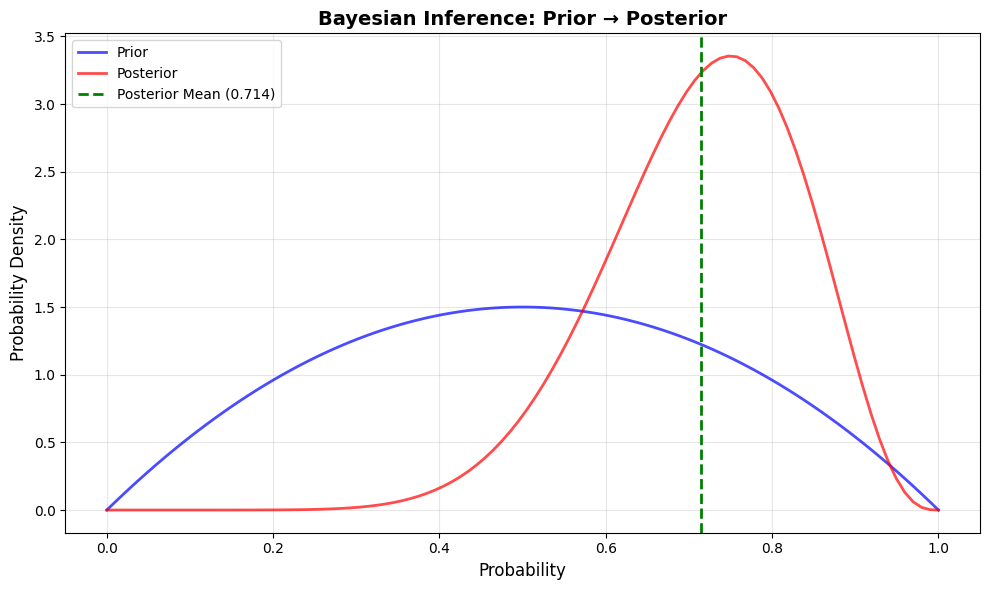


📊 Visualization:
  - Blue: Prior belief
  - Red: Posterior (updated with data)
  - Green: Posterior mean


In [4]:
# Draw the Beta prior next to the Beta posterior to SEE Bayesian updating.
# The shift and narrowing of the curve is exactly what 'the data updated our belief' means.

# Visualize prior and posterior
from scipy.stats import beta

# Evaluate both densities over the whole probability range [0, 1].
x_range = np.linspace(0, 1, 100)
prior_pdf = beta.pdf(x_range, alpha_prior, beta_prior)
posterior_pdf = beta.pdf(x_range, alpha_posterior, beta_posterior)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_range, prior_pdf, 'b-', linewidth=2, label='Prior', alpha=0.7)
ax.plot(x_range, posterior_pdf, 'r-', linewidth=2, label='Posterior', alpha=0.7)
ax.axvline(x=posterior_mean, color='g', linestyle='--', linewidth=2, label=f'Posterior Mean ({posterior_mean:.3f})')
ax.set_xlabel('Probability', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Bayesian Inference: Prior → Posterior', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Visualization:")
print("  - Blue: Prior belief")
print("  - Red: Posterior (updated with data)")
print("  - Green: Posterior mean")

---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding Bayesian inference:

1. **Prior Knowledge**: Can incorporate prior beliefs
2. **Uncertainty**: Can quantify full uncertainty
3. **Regularization**: Priors act as regularization
4. **Next Steps**: Apply to advanced ML models

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand this concept.

**AFTER this notebook**: We understand WHY, HOW, and AFTER!

---

## ✅ Example Complete!

## 📚 References

1. Bayes, T. (1763). *An Essay Towards Solving a Problem in the Doctrine of Chances*. Philosophical Transactions of the Royal Society, 53, 370–418.
2. van de Schoot, R., Depaoli, S., King, R., et al. (2021). *Bayesian Statistics and Modelling*. Nature Reviews Methods Primers, 1, 1. <https://doi.org/10.1038/s43586-020-00001-2>
3. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Ch. 2: Probability Distributions. Springer.